# Mazes and Sudoku: Graphs, Search, and Constraint Propagation

> *A maze is a graph you can see. Sudoku is a constraint you have to feel your way through.*

These two puzzles look nothing alike: one spatial, one numeric, but the algorithms
that solve them share a common skeleton:

1. **Represent the problem** as a structure (graph / candidate sets)
2. **Search** through possible states (BFS, DFS / backtracking)
3. **Prune** as aggressively as possible (walls / constraint propagation)

This notebook demos `maze.py` and `sudoku.py`, visualizes what the algorithms
are actually doing, and shows how different choices produce measurably different outcomes.

In [1]:
# Imports
import sys, random, time, math
from collections import deque
from copy import deepcopy
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

import maze as mz
import sudoku as sd

%matplotlib inline
plt.rcParams.update({
    "figure.facecolor": "#0d1b2a",
    "axes.facecolor":   "#0d1b2a",
    "text.color":       "#dde8f0",
    "axes.edgecolor":   "#2a4a6a",
    "axes.labelcolor":  "#dde8f0",
    "xtick.color":      "#dde8f0",
    "ytick.color":      "#dde8f0",
})
# print("maze.py  :", mz.__file__)
# print("sudoku.py:", sd.__file__)
print("Imports complete.")

Imports complete.


## Part 1: Mazes

### What is a maze?
A grid maze is a graph where each cell is a node and open passages are edges.
The generation algorithm carves that graph; the solvers traverse it.

### Generation: recursive backtracking
Start at (0,0). Pick a random unvisited neighbour, carve a passage, move there, repeat.
When stuck, backtrack. Every cell is visited exactly once; this guarantees a
**perfect maze**: one path between any two cells, no loops, no isolated regions.

**Consequence for solving:** on a perfect maze BFS and DFS find *exactly the same path length*.
The interesting difference is their *exploration pattern*.

In [22]:
W, H = 12, 12
maze_perfect = mz.generate_maze(W, H, seed=7, extra_passages=0)
start = mz.Cell(0, 0)
goal  = mz.Cell(H-1, W-1)

bfs_path, bfs_explored = mz.bfs(maze_perfect, start, goal)
dfs_path, dfs_explored = mz.dfs(maze_perfect, start, goal)

print(f"Perfect {W}x{H} maze")
print(f"  BFS: {len(bfs_path):3d} steps | explored {len(bfs_explored):4d}/{W*H} cells")
print(f"  DFS: {len(dfs_path):3d} steps | explored {len(dfs_explored):4d}/{W*H} cells")
print(f"  Path overhead: {len(dfs_path) - len(bfs_path):+d} steps")
print("On a perfect maze BFS and DFS find the same path length.")
print("Add extra passages (loops) to see them diverge.")

Perfect 12x12 maze
  BFS:  65 steps | explored  106/144 cells
  DFS:  65 steps | explored   72/144 cells
  Path overhead: +0 steps
On a perfect maze BFS and DFS find the same path length.
Add extra passages (loops) to see them diverge.


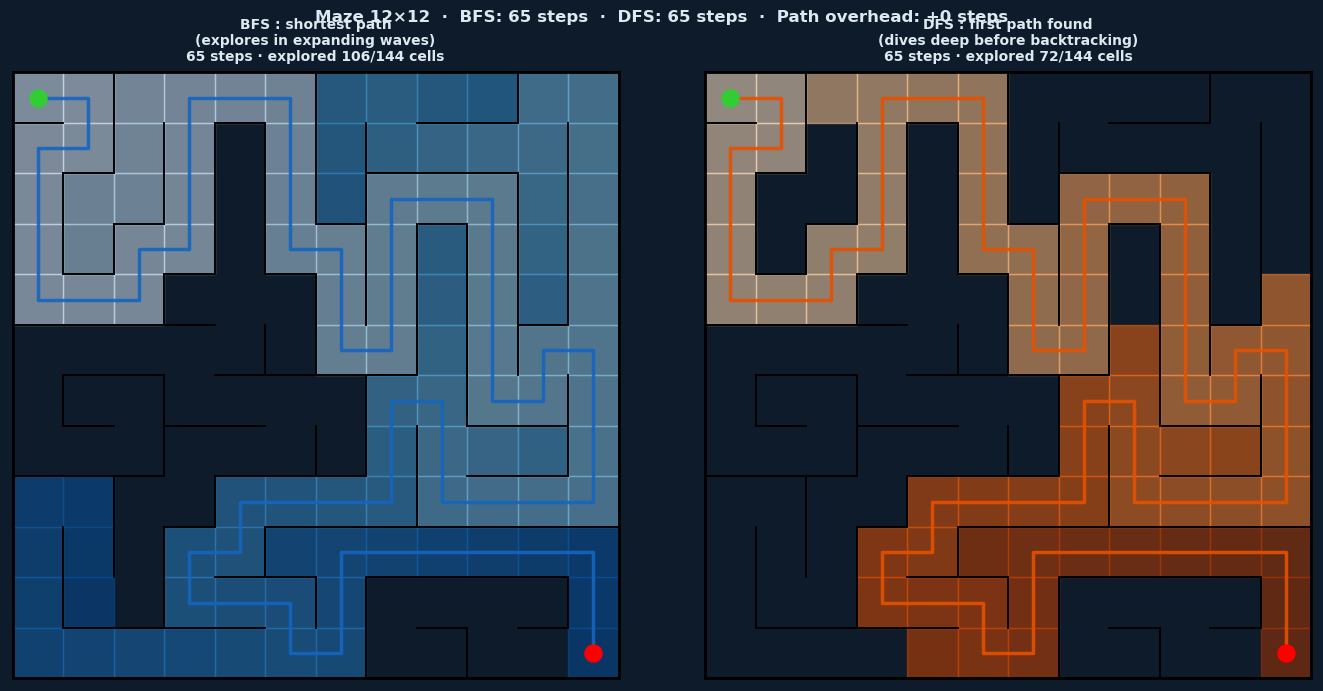

In [23]:
fig = mz.plot_maze(
    maze_perfect, W, H,
    bfs_result=(bfs_path, bfs_explored),
    dfs_result=(dfs_path, dfs_explored),
)
plt.show()

### Reading the heatmap
The colour gradient shows **exploration order** where lighter cells were visited earlier.

- **BFS** expands in concentric rings: cells at distance *d* before any at *d+1*.
  That's why it guarantees the shortest path.
- **DFS** plunges deep immediately, often reaching a far corner early but via a
  winding route. Notice how it can explore a long dead-end arm before the wave
  reaches nearby cells.

### Adding loops: where BFS and DFS actually diverge
A perfect maze has one path so both algorithms must find it. Add extra passages
to create loops and now multiple paths exist and BFS finds the shortest while DFS
finds whichever it reaches first.

In [24]:
maze_loopy = mz.generate_maze(W, H, seed=7, extra_passages=25)

bfs_path_l, bfs_exp_l = mz.bfs(maze_loopy, start, goal)
dfs_path_l, dfs_exp_l = mz.dfs(maze_loopy, start, goal)

print(f"Loopy {W}x{H} maze (25 extra passages)")
print(f"  BFS: {len(bfs_path_l):3d} steps | explored {len(bfs_exp_l):4d}/{W*H} cells")
print(f"  DFS: {len(dfs_path_l):3d} steps | explored {len(dfs_exp_l):4d}/{W*H} cells")
print(f"  Path overhead: {len(dfs_path_l) - len(bfs_path_l):+d} steps")
if len(dfs_path_l) > len(bfs_path_l):
    print("DFS found a longer path: BFS guarantee matters here.")
elif len(dfs_path_l) == len(bfs_path_l):
    print("Got lucky: DFS happened to find the shortest path too.")

Loopy 12x12 maze (25 extra passages)
  BFS:  25 steps | explored  144/144 cells
  DFS:  29 steps | explored   60/144 cells
  Path overhead: +4 steps
DFS found a longer path: BFS guarantee matters here.


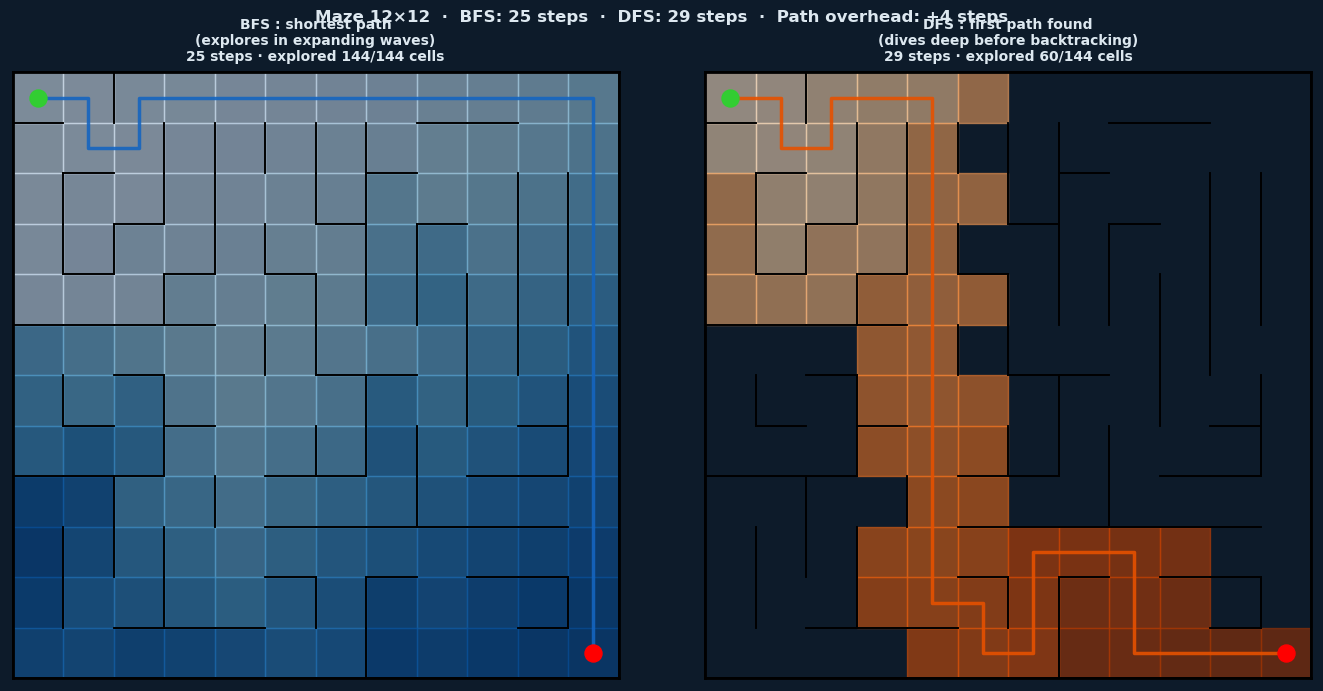

In [25]:
fig = mz.plot_maze(
    maze_loopy, W, H,
    bfs_result=(bfs_path_l, bfs_exp_l),
    dfs_result=(dfs_path_l, dfs_exp_l),
)
plt.show()

### How does path overhead grow with loop count?

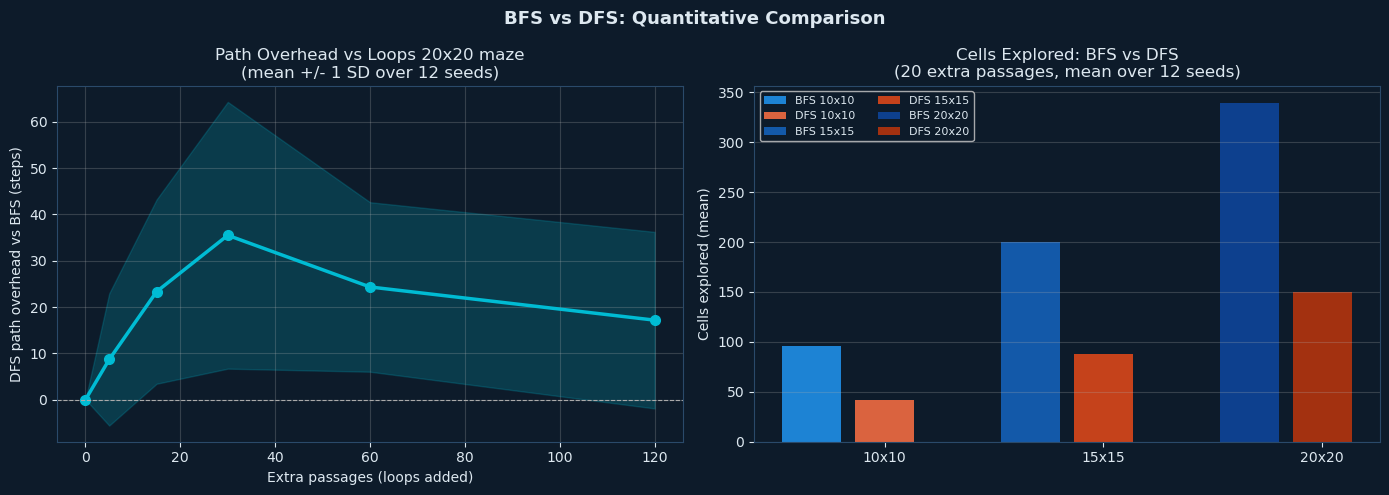

Observations:
  1. Overhead is 0 on perfect mazes: BFS guarantee only matters with loops
  2. Overhead grows with loop count as DFS finds winding alternatives
  3. BFS explores more cells on average, it fans out before going deep


In [26]:
extra_passages_range = [0, 5, 15, 30, 60, 120]
maze_sizes = [(10,10),(15,15),(20,20)]
TRIALS = 12

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: path overhead vs extra passages
ax = axes[0]
W20, H20 = 20, 20
overheads_mean, overheads_std = [], []
for ep in extra_passages_range:
    oh = []
    for seed in range(TRIALS):
        m = mz.generate_maze(W20, H20, seed=seed, extra_passages=ep)
        s, g = mz.Cell(0,0), mz.Cell(H20-1, W20-1)
        bp, _ = mz.bfs(m, s, g)
        dp, _ = mz.dfs(m, s, g)
        oh.append(len(dp) - len(bp))
    overheads_mean.append(np.mean(oh))
    overheads_std.append(np.std(oh))

ep_arr = np.array(extra_passages_range)
om     = np.array(overheads_mean)
os_    = np.array(overheads_std)
ax.fill_between(ep_arr, om - os_, om + os_, alpha=0.2, color="#00bcd4")
ax.plot(ep_arr, om, "o-", color="#00bcd4", linewidth=2.5, markersize=7)
ax.axhline(0, color="#aaa", linewidth=0.8, linestyle="--")
ax.set_xlabel("Extra passages (loops added)")
ax.set_ylabel("DFS path overhead vs BFS (steps)")
ax.set_title(f"Path Overhead vs Loops {W20}x{H20} maze\n(mean +/- 1 SD over {TRIALS} seeds)")
ax.grid(alpha=0.25)

# Right: cells explored
ax = axes[1]
colors_bfs = ["#2196F3","#1565C0","#0D47A1"]
colors_dfs = ["#FF7043","#E64A19","#BF360C"]
for i, (w,h) in enumerate(maze_sizes):
    bfs_exp_counts, dfs_exp_counts = [], []
    for seed in range(TRIALS):
        m = mz.generate_maze(w, h, seed=seed, extra_passages=20)
        s, g = mz.Cell(0,0), mz.Cell(h-1,w-1)
        _, be = mz.bfs(m, s, g)
        _, de = mz.dfs(m, s, g)
        bfs_exp_counts.append(len(be))
        dfs_exp_counts.append(len(de))
    label = f"{w}x{h}"
    ax.bar(i*3,   np.mean(bfs_exp_counts), color=colors_bfs[i], alpha=0.85,
           label=f"BFS {label}", width=0.8)
    ax.bar(i*3+1, np.mean(dfs_exp_counts), color=colors_dfs[i], alpha=0.85,
           label=f"DFS {label}", width=0.8)

ax.set_xticks([1,4,7])
ax.set_xticklabels([f"{w}x{h}" for w,h in maze_sizes])
ax.set_ylabel("Cells explored (mean)")
ax.set_title(f"Cells Explored: BFS vs DFS\n(20 extra passages, mean over {TRIALS} seeds)")
ax.legend(fontsize=8, ncol=2)
ax.grid(axis="y", alpha=0.25)

plt.suptitle("BFS vs DFS: Quantitative Comparison", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Observations:")
print("  1. Overhead is 0 on perfect mazes: BFS guarantee only matters with loops")
print("  2. Overhead grows with loop count as DFS finds winding alternatives")
print("  3. BFS explores more cells on average, it fans out before going deep")

### A larger maze

30x20 maze (40 extra passages)
  BFS: 93 steps | explored 233/600 cells
  DFS: 93 steps | explored 115/600 cells
  DFS overhead: +0 steps


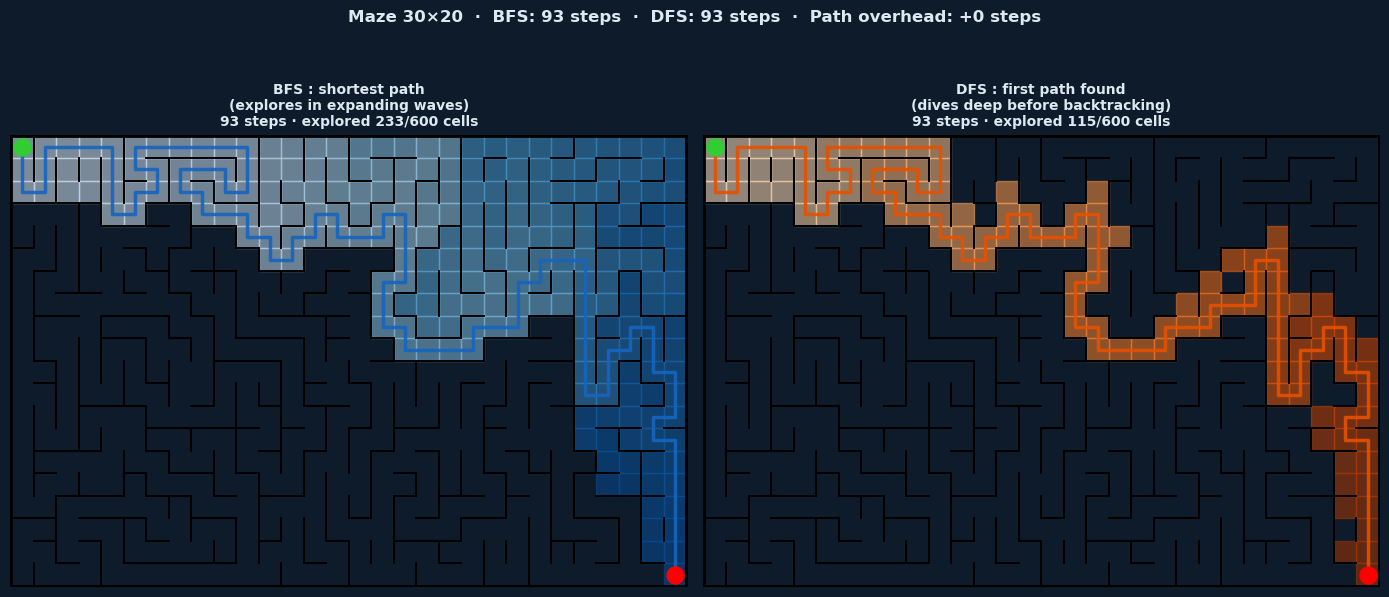

In [27]:
W_big, H_big = 30, 20
maze_big = mz.generate_maze(W_big, H_big, seed=42, extra_passages=40)
s_big = mz.Cell(0, 0)
g_big = mz.Cell(H_big-1, W_big-1)

bfs_p, bfs_e = mz.bfs(maze_big, s_big, g_big)
dfs_p, dfs_e = mz.dfs(maze_big, s_big, g_big)

print(f"30x20 maze (40 extra passages)")
print(f"  BFS: {len(bfs_p)} steps | explored {len(bfs_e)}/{W_big*H_big} cells")
print(f"  DFS: {len(dfs_p)} steps | explored {len(dfs_e)}/{W_big*H_big} cells")
print(f"  DFS overhead: {len(dfs_p) - len(dfs_p):+d} steps")

fig = mz.plot_maze(
    maze_big, W_big, H_big,
    bfs_result=(bfs_p, bfs_e),
    dfs_result=(dfs_p, dfs_e),
)
plt.show()

## Part 2: Sudoku

### What is constraint propagation?
A Sudoku has 81 cells, each with 9 possible digits. Naive backtracking: 9^81 combinations.

**Constraint propagation** prunes this space before any guessing is needed.
When you place a digit, eliminate it from every **peer** cells in the same
row, column, and 3x3 box. Elimination cascades: a peer reduced to one candidate
forces an assignment which propagates further. Many puzzles solve by propagation alone.

**The solver in `sudoku.py`:**
1. **Constraint propagation**: eliminate candidates from 20 peers on every assignment
2. **Backtracking with MRV**: when propagation stalls, pick the cell with the
   *fewest remaining candidates* (minimum remaining values) and try each

In [28]:
def show_candidates(candidates, title="Candidates", ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(9, 9))

    ax.set_xlim(0, 9); ax.set_ylim(0, 9)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_facecolor("#0d1b2a")

    for i in range(10):
        lw  = 2.5 if i % 3 == 0 else 0.5
        col = "#90caf9" if i % 3 == 0 else "#2a4a6a"
        ax.plot([i,i],[0,9], color=col, linewidth=lw, zorder=3)
        ax.plot([0,9],[i,i], color=col, linewidth=lw, zorder=3)

    for ci, cell in enumerate(sd.CELLS):
        r, c = ci // 9, ci % 9
        x0, y0 = c, 8 - r
        cands = candidates[cell]
        if len(cands) == 1:
            digit = next(iter(cands))
            ax.text(x0+0.5, y0+0.5, str(digit),
                    ha="center", va="center", fontsize=15,
                    fontweight="bold", color="#f0f4f8", zorder=4)
            ax.add_patch(mpatches.Rectangle((x0,y0), 1, 1,
                         facecolor="#0d3b5a", zorder=2))
        else:
            for d in range(1, 10):
                dr, dc = (d-1)//3, (d-1)%3
                tx = x0 + 0.18 + dc*0.28
                ty = y0 + 0.72 - dr*0.28
                if d in cands:
                    ax.text(tx, ty, str(d), ha="center", va="center",
                            fontsize=5.5, color="#78909c", zorder=4)

    ax.set_title(title, fontsize=11, fontweight="bold", pad=6)
    if standalone:
        plt.tight_layout(); plt.show()

Initial candidate sets after constraint propagation on the easy puzzle:


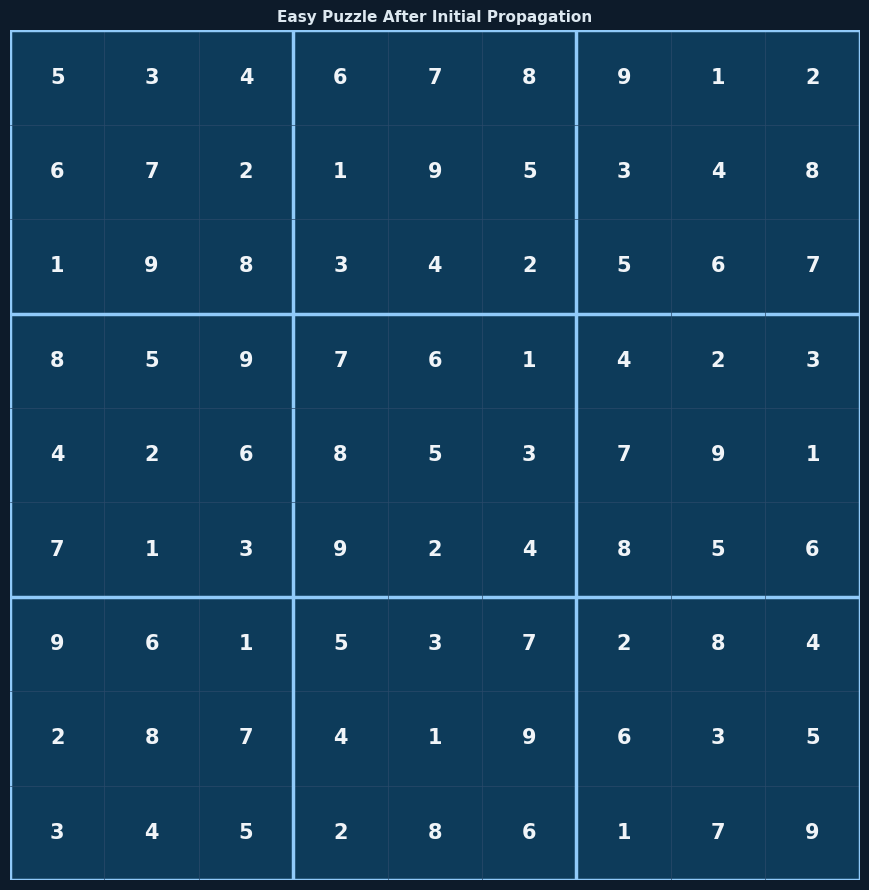

Cells already solved by propagation alone: 81/81


In [29]:
puzzle_easy = sd.PUZZLES["Easy"]
board_easy  = sd.parse_board(puzzle_easy)
cands_easy  = sd.initialise_candidates(board_easy)

print("Initial candidate sets after constraint propagation on the easy puzzle:")
show_candidates(cands_easy, "Easy Puzzle After Initial Propagation")

solved_count = sum(1 for c in cands_easy.values() if len(c) == 1)
print(f"Cells already solved by propagation alone: {solved_count}/81")

### Solving all three example puzzles

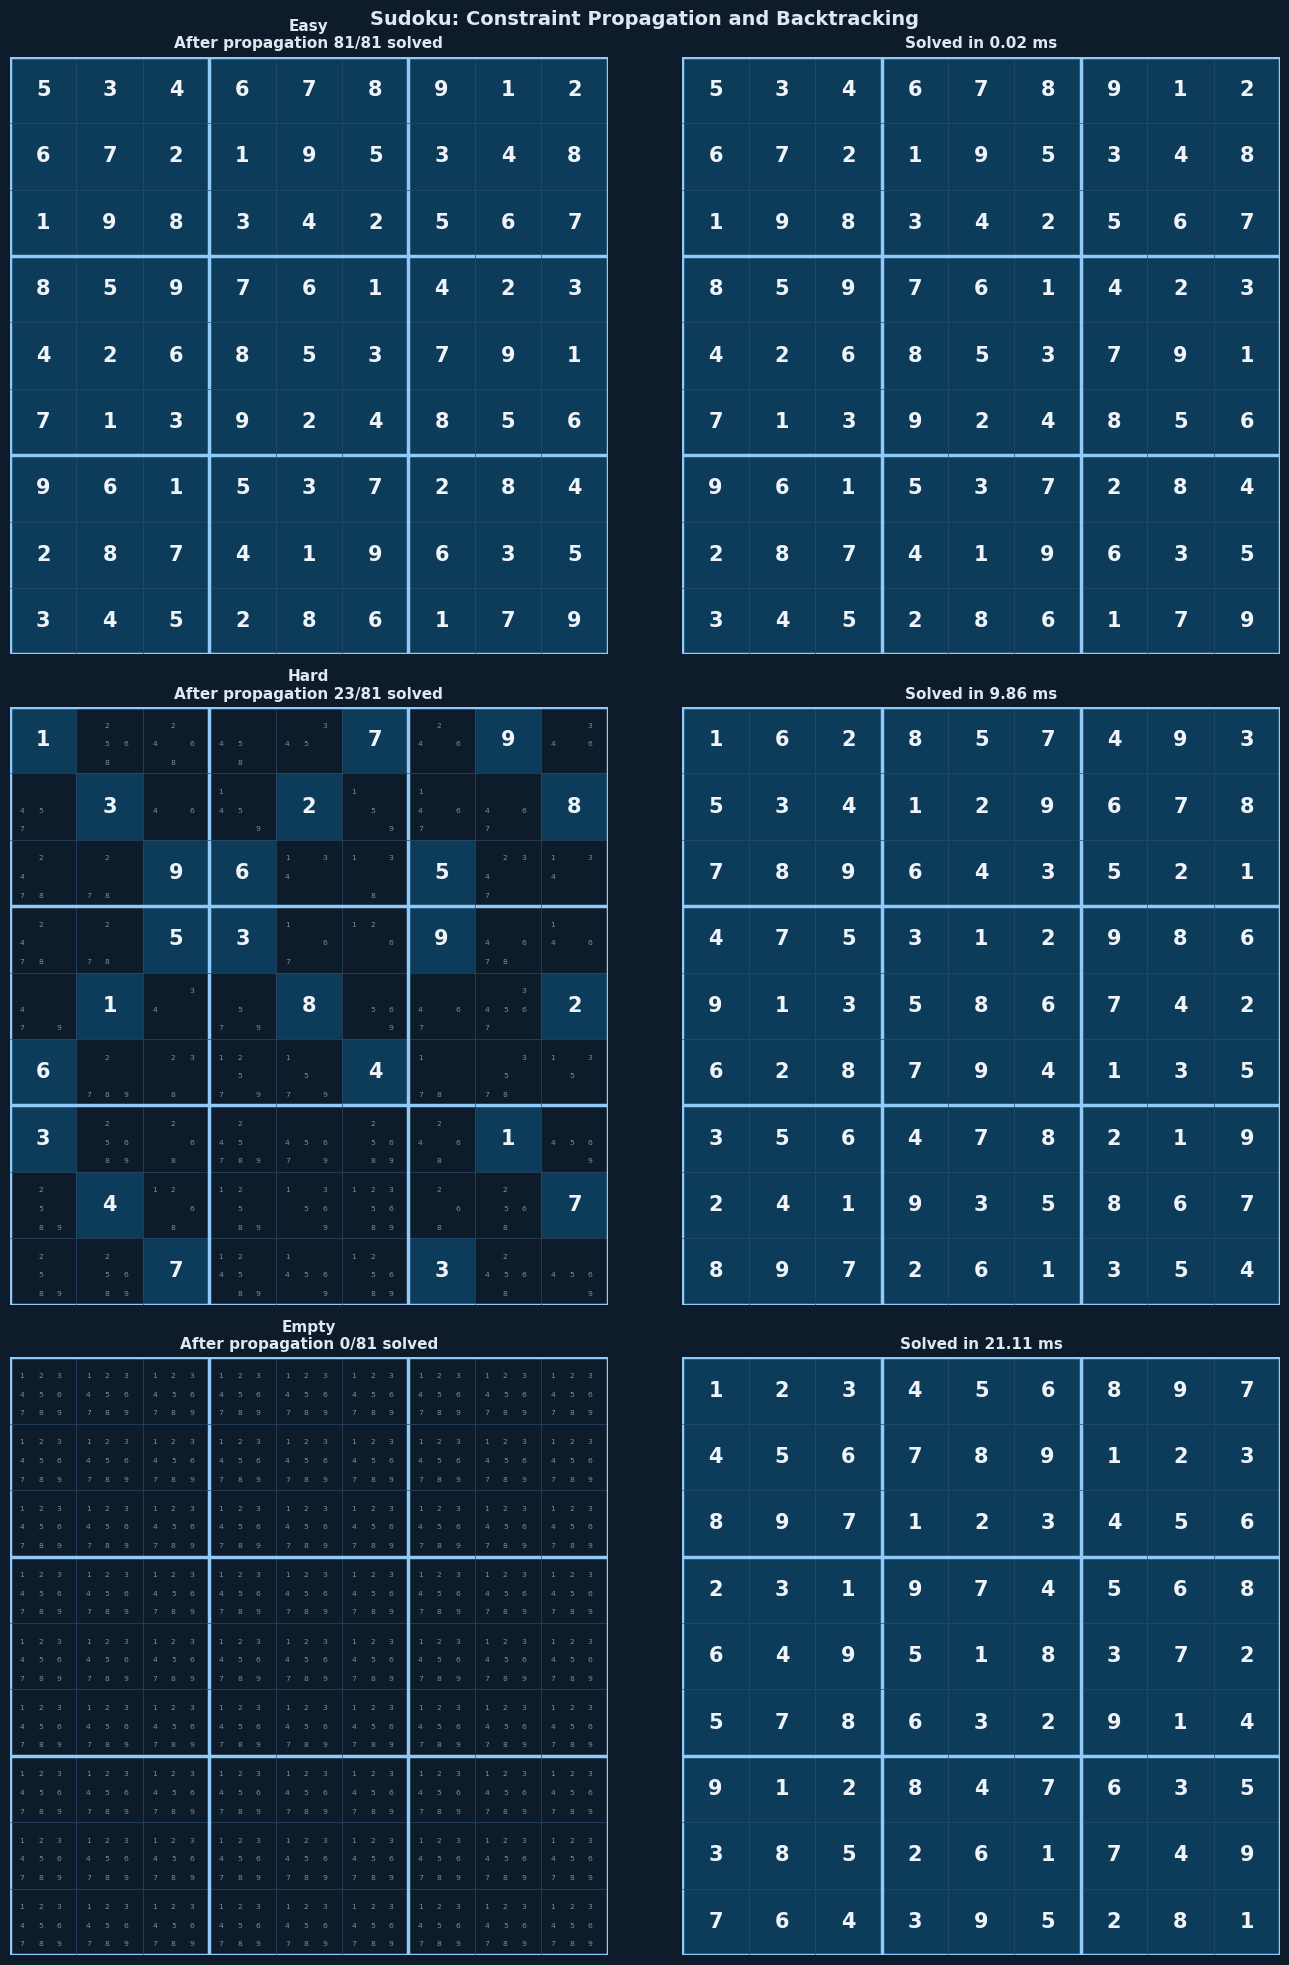

In [30]:
fig, axes = plt.subplots(3, 2, figsize=(14, 20))

for row_idx, (label, puzzle) in enumerate(sd.PUZZLES.items()):
    board  = sd.parse_board(puzzle)
    cands  = sd.initialise_candidates(board)
    t0     = time.perf_counter()
    result = sd.solve(cands)
    elapsed = (time.perf_counter() - t0) * 1000
    solved_count = sum(1 for c in cands.values() if len(c) == 1)

    show_candidates(cands,
        f"{label.split('(')[0].strip()}\nAfter propagation {solved_count}/81 solved",
        ax=axes[row_idx][0])
    if result:
        show_candidates(result, f"Solved in {elapsed:.2f} ms", ax=axes[row_idx][1])
    else:
        axes[row_idx][1].text(0.5, 0.5, "No solution",
            ha="center", va="center",
            transform=axes[row_idx][1].transAxes, fontsize=14)

plt.suptitle("Sudoku: Constraint Propagation and Backtracking",
             fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

In [31]:
print("PROPAGATION POWER")
for label, puzzle in sd.PUZZLES.items():
    board = sd.parse_board(puzzle)
    given = sum(1 for v in board.values() if v is not None)
    cands = sd.initialise_candidates(board)
    after_prop = sum(1 for c in cands.values() if len(c) == 1)
    t0 = time.perf_counter()
    result = sd.solve(cands)
    elapsed = (time.perf_counter() - t0) * 1000
    short_label = label.split("(")[0].strip()
    print(f"  {short_label}")
    print(f"    Clues given        : {given}/81")
    print(f"    After propagation  : {after_prop}/81 solved")
    print(f"    Backtracking needed: {81 - after_prop} cells still open")
    print(f"    Total solve time   : {elapsed:.2f} ms")
    print()

PROPAGATION POWER
  Easy
    Clues given        : 30/81
    After propagation  : 81/81 solved
    Backtracking needed: 0 cells still open
    Total solve time   : 0.02 ms

  Hard
    Clues given        : 23/81
    After propagation  : 23/81 solved
    Backtracking needed: 58 cells still open
    Total solve time   : 11.63 ms

  Empty
    Clues given        : 0/81
    After propagation  : 0/81 solved
    Backtracking needed: 81 cells still open
    Total solve time   : 28.45 ms



### The peer structure
Every cell has exactly **20 peers**: 8 in its row, 8 in its column, 8 in its box
(with overlaps removed). This high connectivity is what makes propagation powerful:
placing one digit immediately constrains 20 other cells.

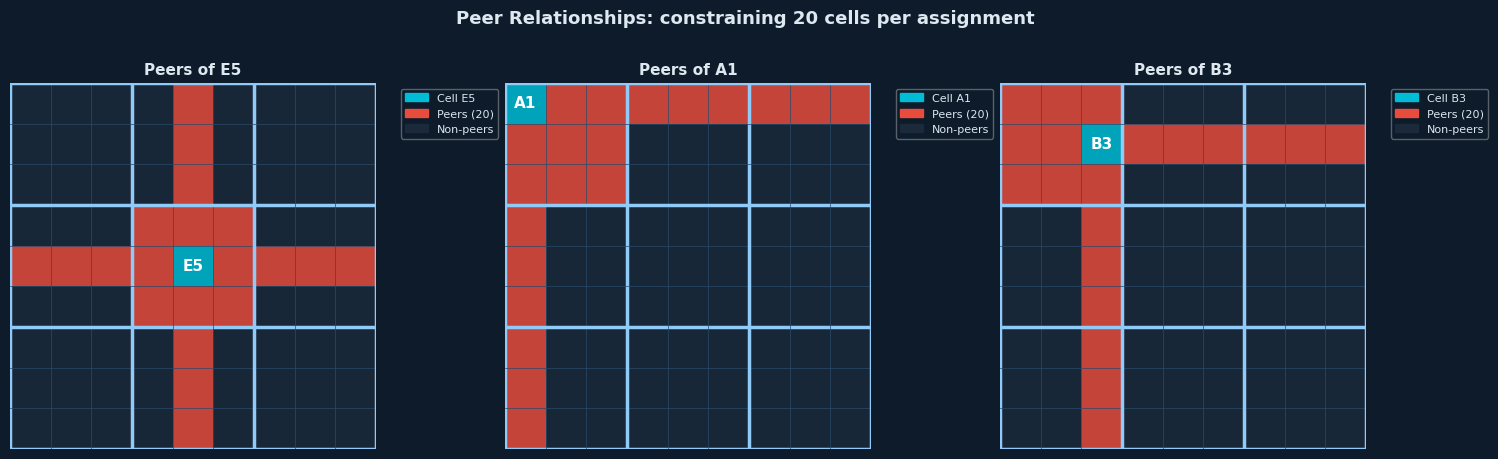

Every cell has exactly 20 peers.


In [32]:
def show_peers(cell_label, ax=None):
    standalone = ax is None
    if standalone:
        fig, ax = plt.subplots(figsize=(5, 5))

    ax.set_xlim(0, 9); ax.set_ylim(0, 9)
    ax.set_aspect("equal"); ax.axis("off")
    ax.set_facecolor("#0d1b2a")

    peers = sd.PEERS[cell_label]
    r_idx = sd.ROWS.index(cell_label[0])
    c_idx = sd.COLS.index(cell_label[1])

    for ci, cell in enumerate(sd.CELLS):
        r, c = ci // 9, ci % 9
        x0, y0 = c, 8 - r
        if cell == cell_label:
            color = "#00bcd4"
        elif cell in peers:
            color = "#e74c3c"
        else:
            color = "#1a2a3a"
        ax.add_patch(mpatches.Rectangle((x0,y0), 1, 1,
                     facecolor=color, alpha=0.85, zorder=1))

    for i in range(10):
        lw  = 2.5 if i % 3 == 0 else 0.5
        col = "#90caf9" if i % 3 == 0 else "#2a4a6a"
        ax.plot([i,i],[0,9],color=col,linewidth=lw,zorder=3)
        ax.plot([0,9],[i,i],color=col,linewidth=lw,zorder=3)

    ax.text(c_idx+0.5, 8-r_idx+0.5, cell_label,
            ha="center", va="center", fontsize=11,
            fontweight="bold", color="white", zorder=4)

    legend = [
        mpatches.Patch(color="#00bcd4", label=f"Cell {cell_label}"),
        mpatches.Patch(color="#e74c3c", label=f"Peers ({len(peers)})"),
        mpatches.Patch(color="#1a2a3a", label="Non-peers"),
    ]
    ax.legend(handles=legend, loc="upper right", fontsize=8,
              framealpha=0.4, bbox_to_anchor=(1.35, 1.0))
    ax.set_title(f"Peers of {cell_label}", fontsize=11, fontweight="bold")
    if standalone:
        plt.tight_layout(); plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, cell in zip(axes, ["E5", "A1", "B3"]):
    show_peers(cell, ax=ax)
plt.suptitle("Peer Relationships: constraining 20 cells per assignment",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()
print(f"Every cell has exactly {len(sd.PEERS['E5'])} peers.")

### Why MRV (Minimum Remaining Values)?
When backtracking is needed, MRV picks the cell with the **fewest remaining candidates**.
If a cell has 2 candidates, we know within 2 guesses whether this branch works.
A cell with 7 candidates could waste 7 guesses. MRV fails fast as it dramatically
shrinks the search tree.

HARD PUZZLE: MRV cell selection trace (first 15 choices)
  Choice  1  depth=0  cell=B3  candidates=2  ██░░░░░░░
  Choice  2  depth=1  cell=B1  candidates=2  ██░░░░░░░
  Choice  3  depth=2  cell=B4  candidates=2  ██░░░░░░░
  Choice  4  depth=3  cell=B7  candidates=2  ██░░░░░░░
  Choice  5  depth=4  cell=A7  candidates=2  ██░░░░░░░
  Choice  6  depth=5  cell=A2  candidates=2  ██░░░░░░░
  Choice  7  depth=6  cell=A4  candidates=2  ██░░░░░░░
  Choice  8  depth=6  cell=A4  candidates=2  ██░░░░░░░
  Choice  9  depth=5  cell=A2  candidates=2  ██░░░░░░░
  Choice 10  depth=6  cell=C1  candidates=2  ██░░░░░░░
  Choice 11  depth=6  cell=C1  candidates=2  ██░░░░░░░
  Choice 12  depth=7  cell=D1  candidates=2  ██░░░░░░░
  Choice 13  depth=8  cell=D2  candidates=2  ██░░░░░░░
  Choice 14  depth=9  cell=F4  candidates=2  ██░░░░░░░


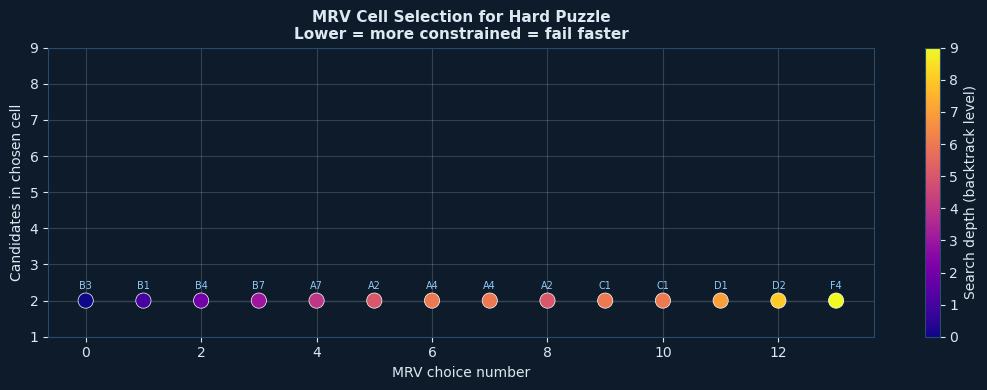

In [33]:
def trace_mrv_choices(puzzle_str, max_choices=15):
    board  = sd.parse_board(puzzle_str)
    cands  = sd.initialise_candidates(board)
    choices = []

    def solve_traced(cands, depth=0):
        if len(choices) >= max_choices:
            return cands if all(len(v)==1 for v in cands.values()) else None
        if all(len(v) == 1 for v in cands.values()):
            return cands
        cell = min((c for c in sd.CELLS if len(cands[c]) > 1),
                   key=lambda c: len(cands[c]))
        choices.append((cell, len(cands[cell]), depth))
        for digit in cands[cell]:
            attempt = deepcopy(cands)
            if sd.assign(attempt, cell, digit):
                result = solve_traced(attempt, depth+1)
                if result: return result
        return None

    solve_traced(cands)
    return choices

hard_key = "Hard (AI Escargot one of the hardest known)"
print("HARD PUZZLE: MRV cell selection trace (first 15 choices)")
choices = trace_mrv_choices(sd.PUZZLES[hard_key])
for i, (cell, n, depth) in enumerate(choices):
    bar = chr(9608)*n + chr(9617)*(9-n)
    print(f"  Choice {i+1:>2}  depth={depth}  cell={cell}  candidates={n}  {bar}")

fig, ax = plt.subplots(figsize=(11, 4))
depths  = [c[2] for c in choices]
n_cands = [c[1] for c in choices]
sc = ax.scatter(range(len(choices)), n_cands, c=depths,
                cmap="plasma", s=120, zorder=3,
                edgecolors="white", linewidth=0.5)
ax.plot(range(len(choices)), n_cands, color="#334455", linewidth=1, zorder=2)
plt.colorbar(sc, ax=ax, label="Search depth (backtrack level)")
for i, (cell, n, d) in enumerate(choices):
    ax.annotate(cell, (i, n), textcoords="offset points",
                xytext=(0,8), ha="center", fontsize=7, color="#90caf9")
ax.set_xlabel("MRV choice number")
ax.set_ylabel("Candidates in chosen cell")
ax.set_title("MRV Cell Selection for Hard Puzzle\nLower = more constrained = fail faster",
             fontsize=11, fontweight="bold")
ax.set_yticks(range(1, 10))
ax.grid(alpha=0.25)
plt.tight_layout()
plt.show()

---
## Try your own puzzle

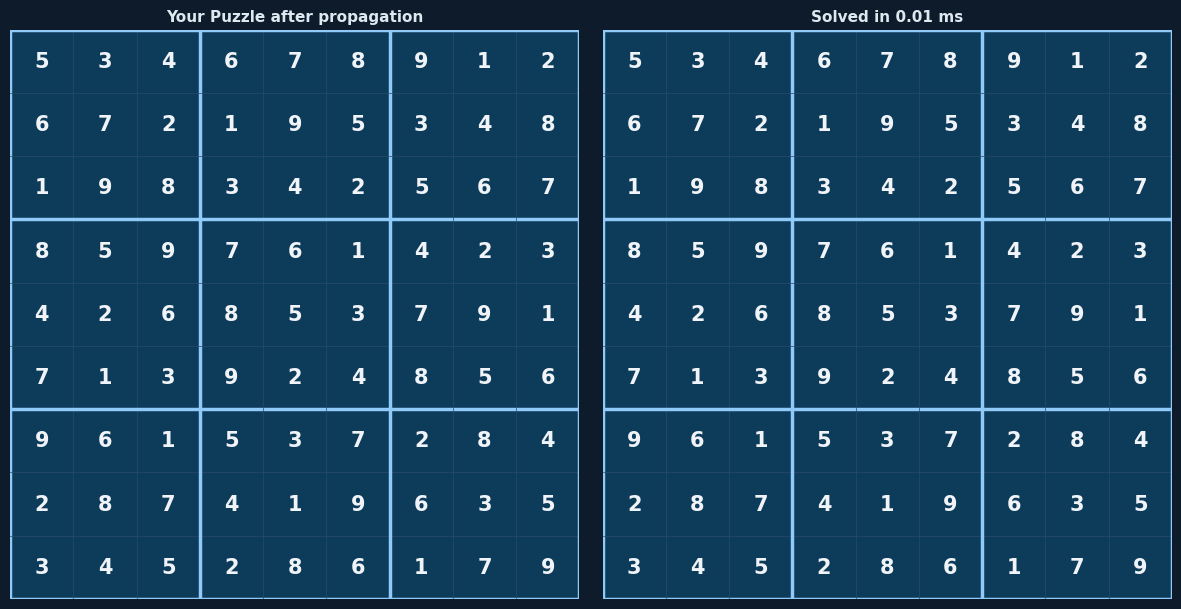

In [34]:
# Use one of the built-in puzzles, or paste a valid 81-char string below
my_puzzle = sd.PUZZLES["Easy"]

# Or paste your own — 81 chars, 0 = empty:
# my_puzzle = "530070000600195000098000060800060003400803001700020006060000280000419005000080079"

board  = sd.parse_board(my_puzzle)
cands  = sd.initialise_candidates(board)

if cands is None:
    print("Contradiction in the given clues: puzzle string is invalid.")
    print(f"Length: {len(my_puzzle)} (must be 81)")
    print(f"String: {my_puzzle}")
else:
    t0 = time.perf_counter()
    result = sd.solve(cands)
    elapsed = (time.perf_counter() - t0) * 1000

    if result:
        fig, axes = plt.subplots(1, 2, figsize=(12, 6))
        show_candidates(cands,  "Your Puzzle after propagation", ax=axes[0])
        show_candidates(result, f"Solved in {elapsed:.2f} ms",     ax=axes[1])
        plt.tight_layout()
        plt.show()
    else:
        print("No solution found: puzzle may be unsolvable.")

## Summary

| | Mazes | Sudoku |
|---|---|---|
| **Representation** | Graph (adjacency dict) | Candidate sets per cell |
| **Core algorithm** | BFS / DFS | Constraint propagation and backtracking |
| **Optimality** | BFS guarantees shortest path | MRV minimizes guessing |
| **Pruning** | Walls block search | Peer elimination cascades |
| **Insights** | BFS/DFS only differ on loopy mazes | Propagation often solves without guessing |

### What to explore next
- **A\* on mazes**: add a heuristic (Manhattan distance to goal) to guide BFS
  toward the goal, visiting fewer cells than plain BFS
- **Maze generation algorithms**: compare recursive backtracking (used here),
  Prim's (random-looking), and Kruskal's (good texture variation)
- **Harder Sudoku techniques**: naked pairs, hidden singles, X-wings:
  constraint patterns that propagation misses but humans use
- **Puzzle difficulty**: measure difficulty by backtracking steps required.
  Easy puzzles need zero; AI Escargot needs many